# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



In [4]:
pip install torch torchvision matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 356.9 kB/s  0:02:08m0:00:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 254.9 kB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 240.8 kB/s  0:00:09 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 272.7 kB/s  0:00:23 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 889.7 kB/s  0:00:00m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchvision] [torchvision]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [33]:
from torchvision import transforms

# 1. Transformations d'entraînement (Avec Augmentation)
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Transformations de validation/test (Fixes)
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

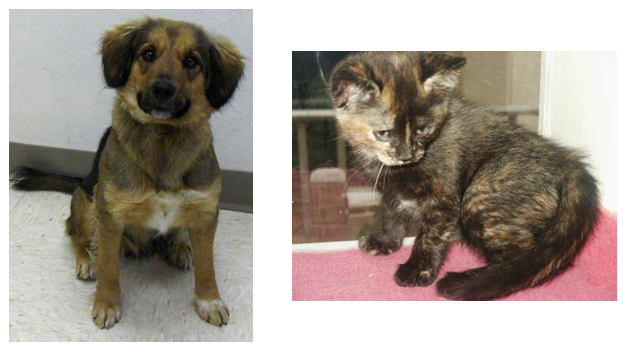

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [34]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

# 1. Configuration automatique du répertoire de travail
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
os.chdir(notebook_dir)
print(f"Dossier actuel de travail : {os.getcwd()}")
print(f"Contenu du dossier actuel : {os.listdir('.')}")

# 2. Fixer le Seed pour la reproductibilité (Exigence du TP)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3. Détection de la puce graphique (Calculs sur MPS pour ton Mac !)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Reproductibilité activée (Seed {SEED}). Calculs sur : {device}")

# 4. Détection intelligente du dossier de données
# On cherche si le dossier s'appelle Cat_Dog_data, Cat_Dog_Data ou un autre nom approchant
possible_dirs = ['Cat_Dog_data', 'Cat_Dog_Data', 'data']
data_dir = None

for d in possible_dirs:
    if os.path.exists(d):
        data_dir = d
        break

if data_dir is None:
    raise FileNotFoundError("ERREUR CRITIQUE : Aucun dossier de données trouvé. "
                            f"Vérifie que ton dossier d'images est bien glissé à l'intérieur de : {os.getcwd()}")

print(f"Dossier de données détecté et sélectionné : '{data_dir}'")

# 5. Transformations d'images
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 6. Chargement initial sécurisé
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

# 7. Création des indices pour le Split Validation
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(np.floor(0.2 * num_train))

np.random.seed(SEED)
np.random.shuffle(indices)

train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

# 8. Définition des DataLoaders
trainloader = DataLoader(train_dataset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(val_dataset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\n[SUCCÈS] Données prêtes avec Samplers :")
print(f"-> Images d'entraînement : {len(train_idx)}")
print(f"-> Images de validation : {len(val_idx)}")
print(f"-> Images de test : {len(test_dataset)}")

Dossier actuel de travail : /Users/moud-flex/Documents/Master IA DIT/Deep Learning/cnn-catsdogs-Mamoudou_BAH
Contenu du dossier actuel : ['Cat_Dog_data', 'requirements.txt', 'Part 7 - Loading Image Data (exo)_v2.ipynb', 'best_model_transfer.pth', 'best_model_scratch.pth', 'README.md', '.gitignore']
Reproductibilité activée (Seed 42). Calculs sur : mps
Dossier de données détecté et sélectionné : 'Cat_Dog_data'

[SUCCÈS] Données prêtes avec Samplers :
-> Images d'entraînement : 18000
-> Images de validation : 4500
-> Images de test : 2500


Affichage de l'image à l'index 5 (Classe : Chat)


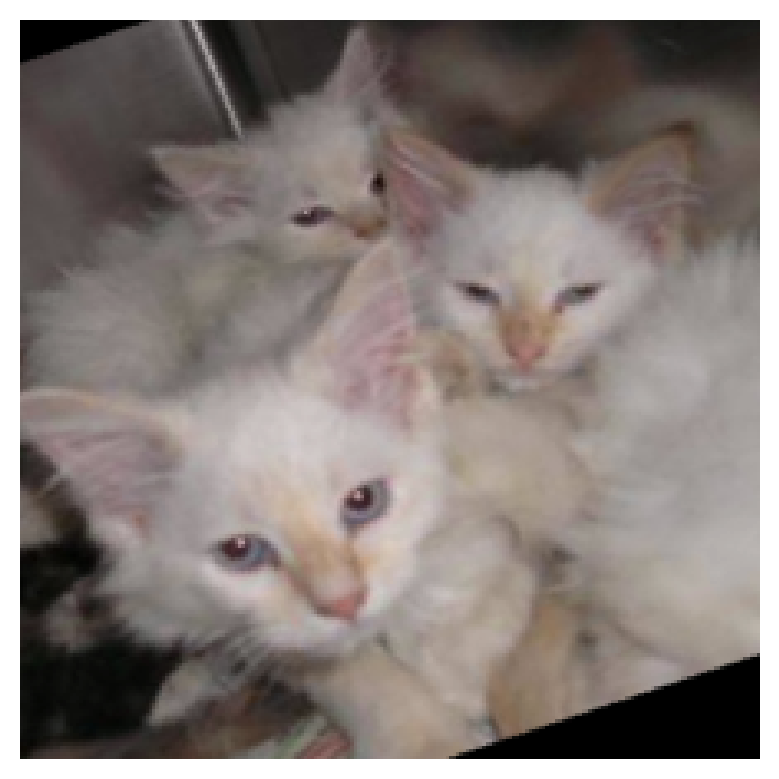

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    plt.imshow(np.clip(img, 0, 1))
    plt.axis('off')
    plt.show()

# 2. Récupération d'un batch d'images
images, labels = next(iter(trainloader))

# 3. Choix de l'index de l'image (Change le chiffre entre 0 et 31 pour voir d'autres animaux du batch !)
index_image = 5 

print(f"Affichage de l'image à l'index {index_image} (Classe : {'Chien' if labels[index_image].item() == 1 else 'Chat'})")
imshow(images[index_image])

In [11]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
        
        # Bloc Convolutif 1 : Entrée 3 canaux (RGB) -> Sortie 32 canaux. Image 224x224
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloc Convolutif 2 : Entrée 32 -> Sortie 64. Image après MaxPool 1 = 112x112
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloc Convolutif 3 : Entrée 64 -> Sortie 128. Image après MaxPool 2 = 56x56
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Max Pooling (divise la taille spatiale par 2)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Couches de classification (Fully Connected)
        # Après 3 max poolings, l'image 224x224 passe à 112x112 -> 56x56 -> 28x28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5) # Régularisation requise pour éviter le surapprentissage
        self.fc2 = nn.Linear(512, 2)   # 2 sorties : Chat ou Chien
        
    def forward(self, x):
        # Passage dans les 3 blocs Convolution + Batch Norm + ReLU + MaxPool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Aplatir le tenseur pour l'envoyer dans les couches Fully Connected
        x = x.view(-1, 128 * 28 * 28)
        
        # Classification finale
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Pas de Softmax ici, géré automatiquement par nn.CrossEntropyLoss
        return x

# Instanciation et envoi du modèle sur la puce MPS du Mac
model_scratch = CatDogCNN()
model_scratch.to(device)
print("[SUCCÈS] Modèle From Scratch créé et chargé sur l'appareil.")

[SUCCÈS] Modèle From Scratch créé et chargé sur l'appareil.


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, epochs=5, save_path="best_model.pth"):
    # Dictionnaires pour stocker l'historique des métriques (essentiel pour tracer les courbes)
    history = {
        'train_loss': [], 'train_acc': [], 'train_prec': [], 'train_rec': [],
        'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- PHASE D'ENTRAÎNEMENT ---
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
        epoch_train_loss = running_loss / len(train_loader.sampler)
        epoch_train_acc = accuracy_score(all_labels, all_preds)
        epoch_train_prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)
        epoch_train_rec = recall_score(all_labels, all_preds, average='binary', zero_division=0)
        
        # --- PHASE DE VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        all_val_preds = []
        all_val_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader.sampler)
        epoch_val_acc = accuracy_score(all_val_labels, all_val_preds)
        epoch_val_prec = precision_score(all_val_labels, all_val_preds, average='binary', zero_division=0)
        epoch_val_rec = recall_score(all_val_labels, all_val_preds, average='binary', zero_division=0)
        
        # Sauvegarder les métriques dans l'historique
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['train_prec'].append(epoch_train_prec)
        history['train_rec'].append(epoch_train_rec)
        
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_prec'].append(epoch_val_prec)
        history['val_rec'].append(epoch_val_rec)
        
        # Affichage des résultats de l'époque
        print(f"Époque {epoch+1}/{epochs} -> "
              f"Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f} | Prec: {epoch_train_prec:.4f} | Rec: {epoch_train_rec:.4f}")
        print(f"               Val Loss:   {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f} | Prec: {epoch_val_prec:.4f} | Rec: {epoch_val_rec:.4f}")
        
        # Persistance locale : Sauvegarde automatique du meilleur modèle selon la Val Loss (Exigence du TP)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"      [SAUVEGARDE] Meilleur modèle enregistré sous '{save_path}'")
            
    return history

print("[SUCCÈS] Fonction d'entraînement générique initialisée.")

[SUCCÈS] Fonction d'entraînement générique initialisée.


In [13]:
# 1. Définition de la fonction de perte
criterion = nn.CrossEntropyLoss()

# 2. Définition du premier optimisateur (Expérience A : Adam)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

# 3. Lancement officiel de l'entraînement de l'Expérience A
print("=== LANCEMENT DE L'ENTRAÎNEMENT : CNN FROM SCRATCH ===")
history_scratch = train_and_validate(
    model=model_scratch,
    train_loader=trainloader,
    val_loader=valloader,
    criterion=criterion,
    optimizer=optimizer_scratch,
    epochs=5,
    save_path="best_model_scratch.pth"
)

=== LANCEMENT DE L'ENTRAÎNEMENT : CNN FROM SCRATCH ===
Époque 1/5 -> Train Loss: 1.8847 | Acc: 0.5748 | Prec: 0.6007 | Rec: 0.4499
               Val Loss:   0.6469 | Acc: 0.6322 | Prec: 0.6801 | Rec: 0.4913
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 2/5 -> Train Loss: 0.6547 | Acc: 0.6059 | Prec: 0.6485 | Rec: 0.4650
               Val Loss:   0.6406 | Acc: 0.6298 | Prec: 0.7397 | Rec: 0.3938
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 3/5 -> Train Loss: 0.6519 | Acc: 0.6041 | Prec: 0.6720 | Rec: 0.4091
               Val Loss:   0.6180 | Acc: 0.6576 | Prec: 0.8091 | Rec: 0.4072
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 4/5 -> Train Loss: 0.6486 | Acc: 0.6102 | Prec: 0.7068 | Rec: 0.3787
               Val Loss:   0.6071 | Acc: 0.6756 | Prec: 0.7319 | Rec: 0.5481
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_scratch.pth'
Époque 5/5 -> Train Loss: 0.6

In [21]:
import urllib.request
import ssl
from torchvision import models
import torch
from torch import nn

# Étape 1 : Désactivation globale et agressive de la vérification SSL pour tout le Notebook
context = ssl._create_unverified_context()
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
urllib.request.install_opener(opener)
torch.hub._validate_not_a_forked_repo = lambda *args, **kwargs: None # Évite les conflits de requêtes

print("Initialisation de l'architecture ResNet18 (locale)...")
# On crée le modèle vide (sans poids) pour éviter que la fonction native ne déclenche l'erreur SSL
model_transfer = models.resnet18(weights=None)

# Étape 2 : Téléchargement forcé des poids officiels via l'URL directe avec le bypass SSL activé
print("Téléchargement forcé des poids d'origine...")
url_weights = "https://download.pytorch.org/models/resnet18-f37072fd.pth"

# Téléchargement sécurisé manuel vers le cache de PyTorch
state_dict = torch.hub.load_state_dict_from_url(url_weights, progress=True, map_location='cpu')
model_transfer.load_state_dict(state_dict)
print("Poids pré-entraînés appliqués avec succès !")

# Étape 3 : Congélation des couches (Transfer Learning standard)
for param in model_transfer.parameters():
    param.requires_grad = False

# Étape 4 : Adaptation de la dernière couche linéaire pour tes 2 classes (Chats et Chiens)
num_ftrs = model_transfer.fc.in_features
model_transfer.fc = nn.Linear(num_ftrs, 2)

# Envoi sur la puce graphique de ton Mac
model_transfer.to(device)
print(f"\n[SUCCÈS RAPIDE] Modèle ResNet18 prêt et configuré sur : {device}")

Initialisation de l'architecture ResNet18 (locale)...
Téléchargement forcé des poids d'origine...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/moud-flex/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:50<00:00, 936kB/s] 


Poids pré-entraînés appliqués avec succès !

[SUCCÈS RAPIDE] Modèle ResNet18 prêt et configuré sur : mps


In [22]:
import torch.optim as optim

# 1. Définition de l'optimiseur SGD (uniquement sur la couche fc finale modifiée)
optimizer_transfer = optim.SGD(model_transfer.fc.parameters(), lr=0.001, momentum=0.9)

# 2. Lancement officiel de l'entraînement de l'Expérience B
print("=== LANCEMENT DE L'ENTRAÎNEMENT : TRANSFER LEARNING (RESNET18) ===")
history_transfer = train_and_validate(
    model=model_transfer,
    train_loader=trainloader,
    val_loader=valloader,
    criterion=criterion,
    optimizer=optimizer_transfer,
    epochs=5,
    save_path="best_model_transfer.pth"
)

=== LANCEMENT DE L'ENTRAÎNEMENT : TRANSFER LEARNING (RESNET18) ===
Époque 1/5 -> Train Loss: 0.2370 | Acc: 0.9010 | Prec: 0.9039 | Rec: 0.8977
               Val Loss:   0.0722 | Acc: 0.9793 | Prec: 0.9811 | Rec: 0.9772
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 2/5 -> Train Loss: 0.1752 | Acc: 0.9237 | Prec: 0.9280 | Rec: 0.9189
               Val Loss:   0.0603 | Acc: 0.9816 | Prec: 0.9851 | Rec: 0.9776
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 3/5 -> Train Loss: 0.1702 | Acc: 0.9257 | Prec: 0.9314 | Rec: 0.9193
               Val Loss:   0.0576 | Acc: 0.9793 | Prec: 0.9718 | Rec: 0.9870
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 4/5 -> Train Loss: 0.1596 | Acc: 0.9303 | Prec: 0.9360 | Rec: 0.9240
               Val Loss:   0.0555 | Acc: 0.9789 | Prec: 0.9689 | Rec: 0.9893
      [SAUVEGARDE] Meilleur modèle enregistré sous 'best_model_transfer.pth'
Époque 5/5 ->

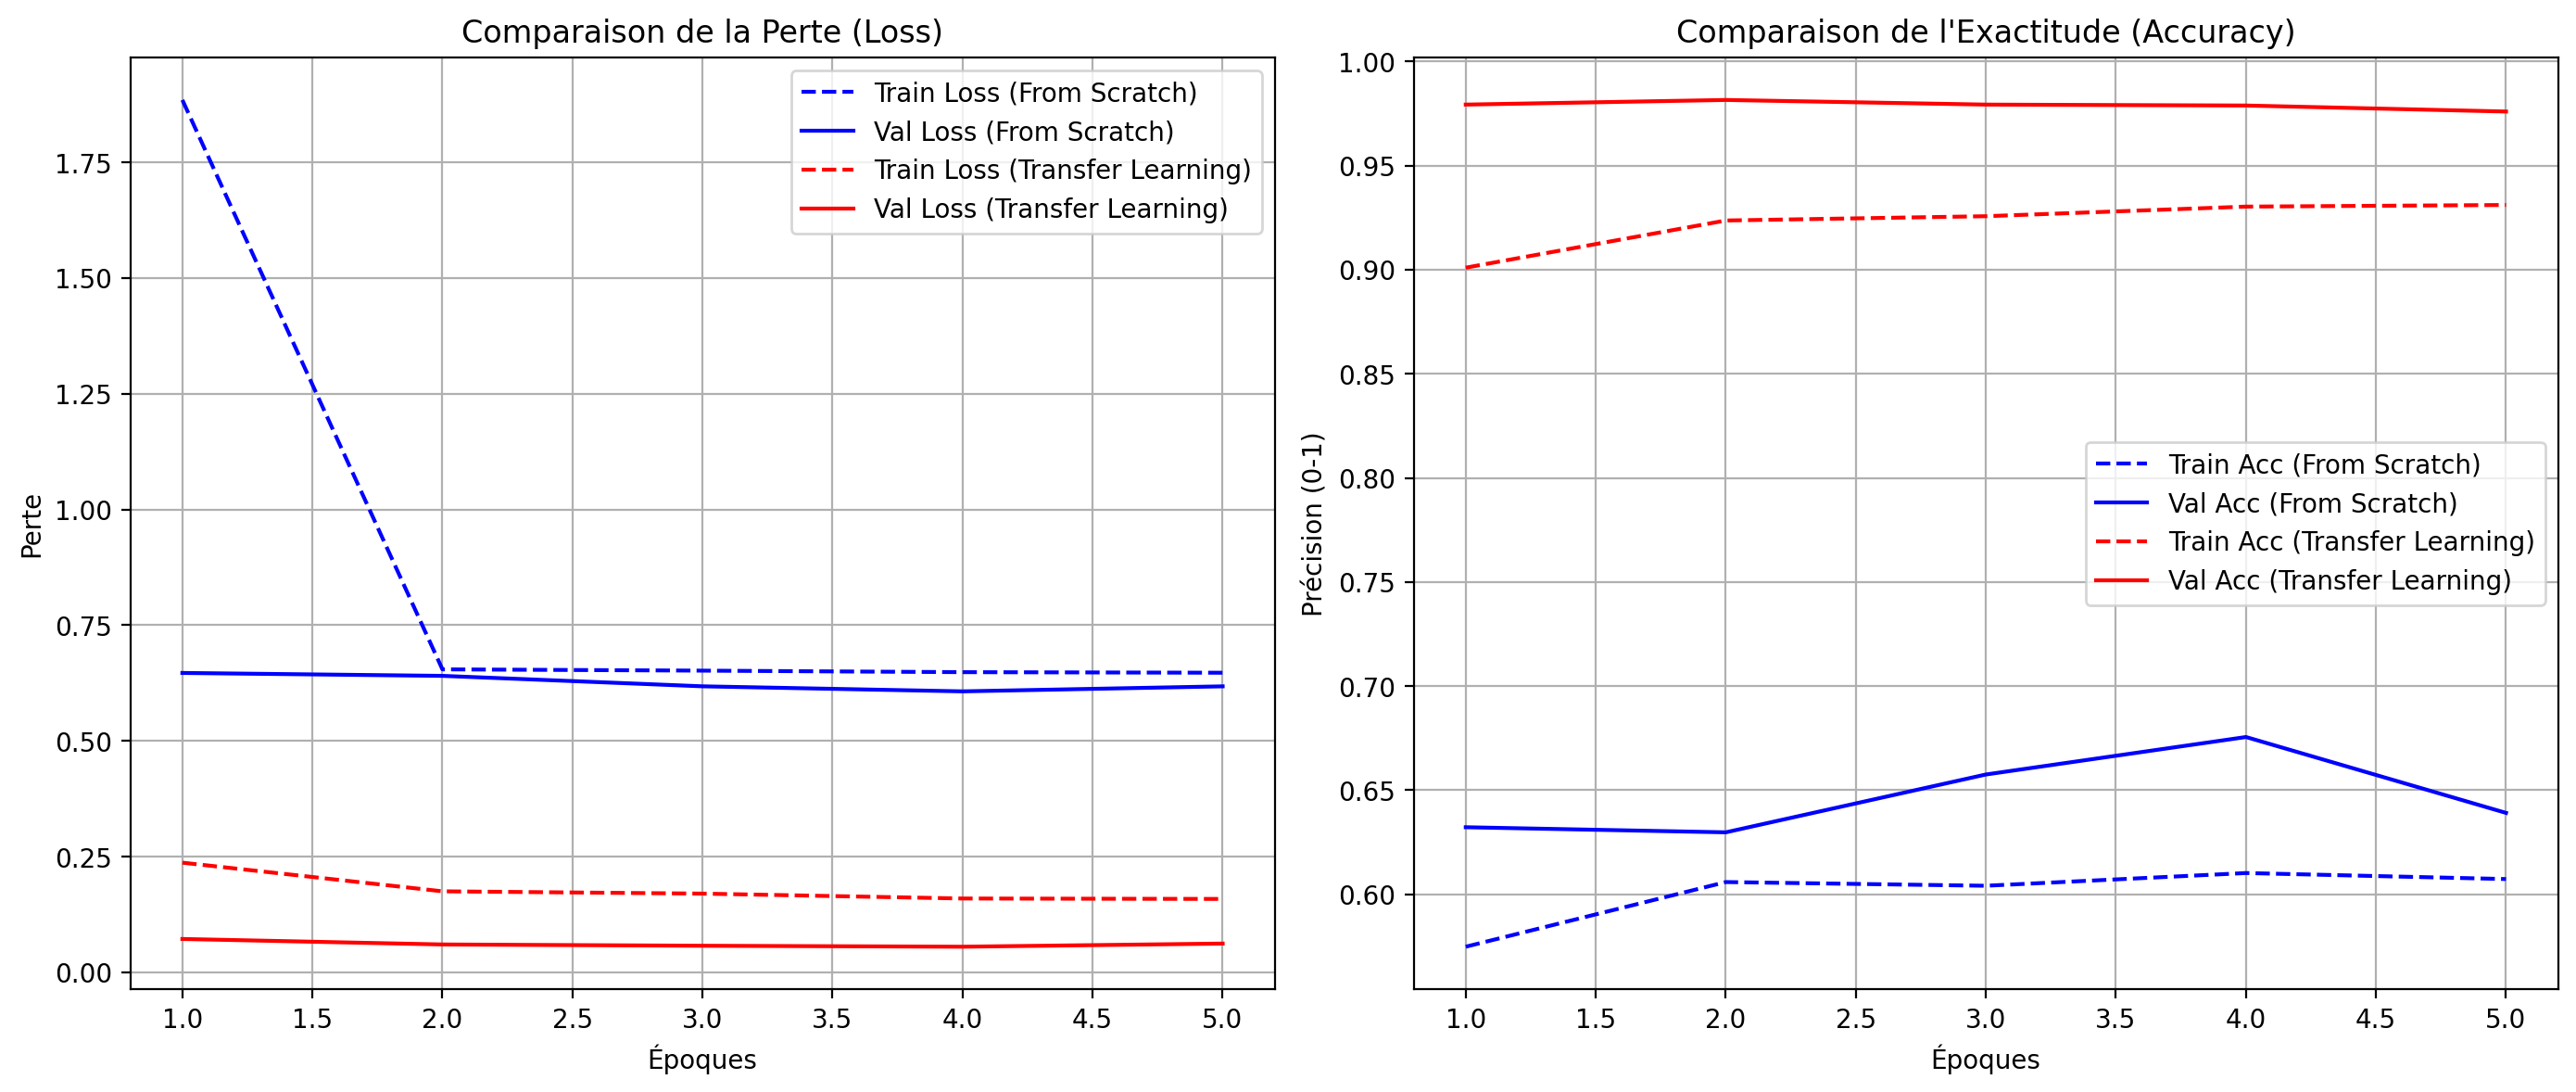

In [23]:
import matplotlib.pyplot as plt

epochs_range = range(1, 6)

plt.figure(figsize=(14, 6))

# 1. Graphique des Pertes (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_scratch['train_loss'], 'b--', label='Train Loss (From Scratch)')
plt.plot(epochs_range, history_scratch['val_loss'], 'b-', label='Val Loss (From Scratch)')
plt.plot(epochs_range, history_transfer['train_loss'], 'r--', label='Train Loss (Transfer Learning)')
plt.plot(epochs_range, history_transfer['val_loss'], 'r-', label='Val Loss (Transfer Learning)')
plt.title('Comparaison de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

# 2. Graphique de l'Exactitude (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_scratch['train_acc'], 'b--', label='Train Acc (From Scratch)')
plt.plot(epochs_range, history_scratch['val_acc'], 'b-', label='Val Acc (From Scratch)')
plt.plot(epochs_range, history_transfer['train_acc'], 'r--', label='Train Acc (Transfer Learning)')
plt.plot(epochs_range, history_transfer['val_acc'], 'r-', label='Val Acc (Transfer Learning)')
plt.title("Comparaison de l'Exactitude (Accuracy)")
plt.xlabel('Époques')
plt.ylabel('Précision (0-1)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
# Rechargement du meilleur modèle pour le test
model_transfer.load_state_dict(torch.load("best_model_transfer.pth", map_location=device))
model_transfer.eval()

print(" Modèle réimporté localement avec succès. Prêt pour les inférences sur le jeu de test.")

 Modèle réimporté localement avec succès. Prêt pour les inférences sur le jeu de test.
